# LING 498 Hackathon — Prompt 11

## Stress templates (syllable stress patterns)

**Category:** Phonology / phonetics interface

**Question:** Do primary-stress templates (e.g., 1-0, 0-1-0) show Zipf-like distributions?

- **Data:** CMUdict phones with stress digits preserved.
- **Items to Count:** Stress strings from vowel phones only; keep words with ≥2 vowels.

**Steps**
- Extract stress digits from vowel phones in each pronunciation.
- Make a template string (join with "-").
- Run Zipf report/plot.
- Interpret: why a few templates dominate; how morphology/borrowing could shift the distribution.

**Deliverable:** Top-15 stress templates + one explanation of skew + one limitation.

In [1]:
import re
from nltk.corpus import cmudict
from nltk import FreqDist

In [2]:
# Helper functions
def zipf_prep(items, min_count=1):
    fd = FreqDist(items)
    # drop ultra-rare if desired
    items2 = [(k,v) for k,v in fd.items() if v >= min_count]
    items2.sort(key=lambda kv: kv[1], reverse=True)
    return items2  # list of (item, count) sorted

def zipf_quick_report(items, title="", topn=15):
    ranked = zipf_prep(items)
    print(f"\n=== {title} ===")
    print(f"Stress Template Types: {len(ranked)} | Stress Templates: {sum(c for _,c in ranked)}")
    print("Top templates:")
    for i,(k,v) in enumerate(ranked[:topn], start=1):
        print(f"{i:>2}. {str(k)[:40]:<40} {v}")
    # simple “Zipf-ness” sanity check (no regression): f1 ~ 2*f2 ~ 3*f3?
    if len(ranked) >= 5:
        f1,f2,f3,f4,f5 = [ranked[i][1] for i in range(5)]
        print("\nHeuristic ratios (closer to 1 is more Zipf-like):")
        print(" f1/(2*f2) =", round(f1/(2*f2), 3))
        print(" f1/(3*f3) =", round(f1/(3*f3), 3))
        print(" f1/(4*f4) =", round(f1/(4*f4), 3))
        print(" f1/(5*f5) =", round(f1/(5*f5), 3))
    return ranked

# Optional plotting cell (instructor can pre-enable if matplotlib is available)
def zipf_plot(ranked, n=1000, title="Zipf Plot"):
    import matplotlib.pyplot as plt
    ranks = list(range(1, min(n, len(ranked)) + 1))
    freqs = [ranked[i - 1][1] for i in ranks]
    plt.figure(figsize=(7, 5))
    plt.loglog(ranks, freqs, marker='o', linestyle='-', markersize=4)
    plt.xlabel("Rank (log scale)")
    plt.ylabel("Frequency (log scale)")
    plt.title(title)
    plt.grid(True, which="both", linestyle="--", alpha=0.4)
    plt.tight_layout()
    plt.show()

In [3]:
# load the phonetic dictionary (scaffold)
cmu_dict = cmudict.dict()

In [4]:
# extract stress templates
def get_stress_template(phones):
    stress_digits = []

    for phone in phones:

        # Check whether the phone is a stressed vowel
        if re.search(r"\d", phone):
            stress = phone[-1]
            stress_digits.append(stress)

    if len(stress_digits) >= 2:
        return "-".join(stress_digits)

    return ""

In [5]:
# test get_stress_template function
test_stress_digits = [
    ["AH0", "B", "AW1", "T"],
    ["AE2", "K", "AH0", "D", "EH1", "M", "IH0", "K"],
    ["K", "AE1", "T"],
    ["P", "ER0", "M", "IH1", "T"]
]

for phones in test_stress_digits:
    print(phones)
    print(get_stress_template(phones))
    print()

['AH0', 'B', 'AW1', 'T']
0-1

['AE2', 'K', 'AH0', 'D', 'EH1', 'M', 'IH0', 'K']
2-0-1-0

['K', 'AE1', 'T']


['P', 'ER0', 'M', 'IH1', 'T']
0-1



In [6]:
# collect stress templates
stress_templates = []

for word in cmu_dict:
    pronunciations = cmu_dict[word]

    for phones in pronunciations:
        template = get_stress_template(phones)

        if template != "":
            stress_templates.append(template)


=== CMUdict Stress Templates ===
Stress Template Types: 274 | Stress Templates: 116806
Top templates:
 1. 1-0                                      45619
 2. 0-1-0                                    13876
 3. 1-0-0                                    13298
 4. 1-2                                      7734
 5. 0-1                                      6604
 6. 1-0-2                                    4857
 7. 0-1-0-0                                  3855
 8. 2-0-1-0                                  3202
 9. 1-0-2-0                                  2006
10. 1-2-0                                    1856
11. 0-0-1-0                                  1741
12. 2-0-1-0-0                                1305
13. 2-1-0                                    1076
14. 1-0-0-0                                  930
15. 2-0-1                                    833

Heuristic ratios (closer to 1 is more Zipf-like):
 f1/(2*f2) = 1.644
 f1/(3*f3) = 1.144
 f1/(4*f4) = 1.475
 f1/(5*f5) = 1.382


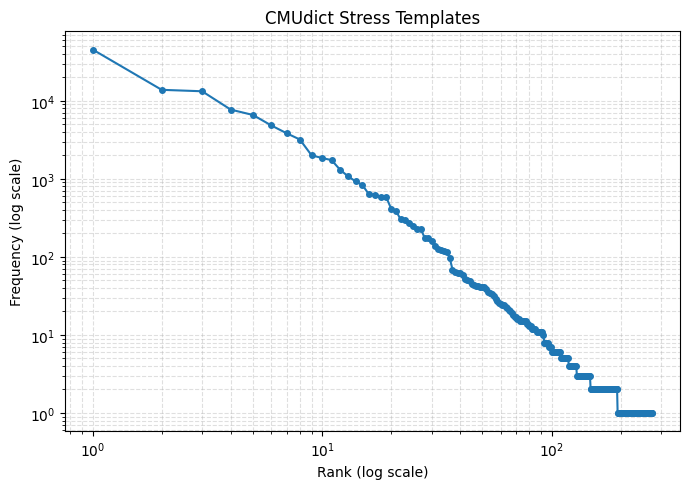

In [7]:
zipf_quick_report(stress_templates, title="CMUdict Stress Templates")

ranked_templates = zipf_prep(stress_templates)

zipf_plot(ranked_templates, title="CMUdict Stress Templates")